
### MATH550 HW1

#### Problem 1

Steady Stokes flow on the unit square with viscosity $\mu = 1$:

$$\mu \nabla^2 \mathbf{u} - \nabla P = \mathbf{f}, \qquad \nabla \cdot \mathbf{u} = 0$$

with $\mathbf{u} = (U, V)$ and $\mathbf{f} = (f, g)$. Written out:

$$\mu\left(\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2}\right) - \frac{\partial P}{\partial x} = f, \qquad
\mu\left(\frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2}\right) - \frac{\partial P}{\partial y} = g, \qquad
\frac{\partial U}{\partial x} + \frac{\partial V}{\partial y} = 0$$

##### Boundary conditions

- Periodic in x: the flow leaving at x = 1 re-enters at x = 0.
- Top and bottom walls (y = 0 and y = 1): U = 0 and V = -3.5.
- Pressure appears only through its gradient, so it is fixed up to a constant. Pressure is pinned (pin P = 0) in one cell to remove that constant.

In [1]:
#imports

import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import cmocean
import time

#Plot styling
#plt.rcParams['font.family'] = 'Arial'
plt.rcParams.update({
    'font.family': 'Arial',
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

In [2]:
#Setup domain

xmin, xmax = 0.0, 1.0
ymin, ymax = 0.0, 1.0
Lx, Ly = xmax - xmin, ymax - ymin
L=Lx=Ly
Nx, Ny = 64, 64
mu = 1

#### Staggered grid

Each unknown lives at a different place in a cell of size h:

- P at cell centers (xc, yc): Nx x Ny values.
- U on vertical faces (xf, yc): the left edge of each cell. U is not on the walls, so a ghost row is added below the bottom wall and above the top wall, giving Nx x (Ny + 2) values. The wall condition is imposed by averaging: $\tfrac12(U_{\text{ghost}} + U_{\text{interior}}) = 0$.
- V on horizontal faces (xc, yf): the bottom edge of each cell, including the walls, giving Nx x (Ny + 1) values. The wall rows are set directly to V = -3.5.

With this layout every derivative is a centered difference over one cell width.

#### Discrete equations

At an interior U face, the 5-point Laplacian and the pressure difference across the face:

$$\frac{\mu}{h^2}\left(U_{i-1,j} + U_{i+1,j} + U_{i,j-1} + U_{i,j+1} - 4U_{i,j}\right) - \frac{P_{i,j} - P_{i-1,j}}{h} = f_{i,j}$$

The V rows are the same with the pressure difference taken in y. In each cell, continuity is

$$\frac{U_{i+1,j} - U_{i,j}}{h} + \frac{V_{i,j+1} - V_{i,j}}{h} = 0$$

All unknowns go into one vector $[U, V, P]$ and all equations into one sparse matrix $A$, so the problem is $A\mathbf{x} = \mathbf{b}$. The U rows come first, then V, then P (offsets offU, offV, offP). The periodic wraparound is handled by the `left` and `right` indices.

#### Manufactured solution

To check the code we choose

$$U = \sin(2\pi y)\sin(2\pi x), \qquad V = -3.5 + \cos(2\pi x)\left(\cos(2\pi y) - 1\right), \qquad P = \sin(2\pi y)\cos(2\pi x)$$

substitute them into the momentum equations, and take the leftover terms as f and g. These fields are divergence free, periodic in x, and give U = 0 and V = -3.5 on the walls, so they satisfy every boundary condition. The solver should then reproduce them up to discretization error.

`build_system` has two switches used only in Problem 3: `darcy=True` adds a drag term and `source=False` sets f = g = 0. With the defaults it is the Stokes system above.

In [3]:
#Functions

def make_grid(Nx, Ny):
    h = Lx / Nx
    xc = xmin + (np.arange(Nx) + 0.5) * h              # x centers
    yc = ymin + (np.arange(Ny) + 0.5) * h              # y centers
    xf = xmin + np.arange(Nx) * h                      # x edges; x = 1 is the same point as x = 0 (periodic)
    yf = ymin + np.arange(Ny + 1) * h                  # y edges
    yg = np.concatenate(([ymin - 0.5 * h], yc, [ymax + 0.5 * h]))   # ghost heights for U
    return h, xc, yc, xf, yf, yg

def U_an(x,y):
    return np.sin(2 * np.pi * y) * np.sin(2 * np.pi * x)

def V_an(x, y):
    return -3.5 + np.cos(2 * np.pi * x) * (np.cos(2 * np.pi * y) - 1)

def P_an(x, y):
    return np.sin(2 * np.pi * y) * np.cos(2 * np.pi * x)
    
def f(x, y):
    return -(np.sin(2 * np.pi * y) * np.sin(2 * np.pi * x) * (8 * np.pi**2 - 2 * np.pi))

def g(x, y):
    return (-4 * np.pi**2 * np.cos (2 * np.pi * x)) * ((2 * np.cos (2 * np.pi * y)) - 1) - (2 * np.pi * np.cos(2 * np.pi * y) * np.cos(2 * np.pi * x))

def idx ( i, j, nx):
    return i + j*nx

def build_system(Nx, Ny, darcy=False, alpha=None, source=True):
    # darcy  = True : add the drag term -alpha(x, y) * u to the U and V rows (Stokes-Darcy)
    # alpha  : function alpha(x, y) = mu / kappa, only used when darcy = True
    # source = True : use the manufactured f and g; False sets f = g = 0
    h, xc, yc, xf, yf, yg = make_grid(Nx, Ny) #h=dx=dy (square doamin)

    nU = Nx * (Ny + 2)
    nV = Nx * (Ny + 1)
    nP = Nx * Ny
    N = nU + nV + nP

    # starting rows for each variable
    offU = 0
    offV = nU
    offP = nU + nV

    row, col, val = [], [], []
    rhs = np.zeros(N)

    # U rows
    for j in range(Ny + 2):
        for i in range(Nx):
            # periodic boundary conditions
            left  = Nx - 1 if i == 0 else i - 1
            right = 0 if i == Nx - 1 else i + 1
            k = offU + idx(i, j, Nx)

            if j == 0:
                # bottom ghost points: average with U above = 0
                row.append(k); col.append(offU + idx(i, 0, Nx)); val.append(0.5)
                row.append(k); col.append(offU + idx(i, 1, Nx)); val.append(0.5)
            elif j == Ny + 1:
                # top ghost points: average with U below = 0
                row.append(k); col.append(offU + idx(i, Ny + 1, Nx)); val.append(0.5)
                row.append(k); col.append(offU + idx(i, Ny, Nx));     val.append(0.5)
            else:
                # Laplacian of U
                row.append(k); col.append(offU + idx(left, j, Nx));  val.append(mu / h**2)
                row.append(k); col.append(offU + idx(right, j, Nx)); val.append(mu / h**2)
                row.append(k); col.append(offU + idx(i, j - 1, Nx)); val.append(mu / h**2)
                row.append(k); col.append(offU + idx(i, j + 1, Nx)); val.append(mu / h**2)
                diag = -4 * mu / h**2
                if darcy:
                    diag -= alpha(xf[i], yg[j])               # Darcy drag at the U point
                row.append(k); col.append(k);                        val.append(diag)
                # -dP/dx: P cell right of this face is i, left is left; P row is j-1
                row.append(k); col.append(offP + idx(i, j - 1, Nx));    val.append(-1 / h)
                row.append(k); col.append(offP + idx(left, j - 1, Nx)); val.append(1 / h)
                rhs[k] = f(xf[i], yg[j]) if source else 0.0

    # V rows
    for j in range(Ny + 1):
        for i in range(Nx):
            left  = Nx - 1 if i == 0 else i - 1
            right = 0 if i == Nx - 1 else i + 1
            k = offV + idx(i, j, Nx)

            if j == 0 or j == Ny:
                # wall: V = -3.5
                row.append(k); col.append(k); val.append(1.0)
                rhs[k] = -3.5
            else:
                # Laplacian of V
                row.append(k); col.append(offV + idx(left, j, Nx));  val.append(mu / h**2)
                row.append(k); col.append(offV + idx(right, j, Nx)); val.append(mu / h**2)
                row.append(k); col.append(offV + idx(i, j - 1, Nx)); val.append(mu / h**2)
                row.append(k); col.append(offV + idx(i, j + 1, Nx)); val.append(mu / h**2)
                diag = -4 * mu / h**2
                if darcy:
                    diag -= alpha(xc[i], yf[j])               # Darcy drag at the V point
                row.append(k); col.append(k);                        val.append(diag)
                # -dP/dy: P cell above this face is j, below is j-1
                row.append(k); col.append(offP + idx(i, j, Nx));     val.append(-1 / h)
                row.append(k); col.append(offP + idx(i, j - 1, Nx)); val.append(1 / h)
                rhs[k] = g(xc[i], yf[j]) if source else 0.0

    # P rows
    for j in range(Ny):
        for i in range(Nx):
            right = 0 if i == Nx - 1 else i + 1
            k = offP + idx(i, j, Nx)

            if i == 0 and j == 0:
                # pin pressure in one cell to remove the free constant
                row.append(k); col.append(k); val.append(1.0)
                rhs[k] = 0.0
            else:
                # continuity: (U_right - U_left)/h + (V_top - V_bottom)/h = 0
                row.append(k); col.append(offU + idx(right, j + 1, Nx)); val.append(1 / h)
                row.append(k); col.append(offU + idx(i, j + 1, Nx));     val.append(-1 / h)
                row.append(k); col.append(offV + idx(i, j + 1, Nx));     val.append(1 / h)
                row.append(k); col.append(offV + idx(i, j, Nx));         val.append(-1 / h)
                rhs[k] = 0.0 #Divergence free

    A = sp.coo_matrix((val, (row, col)), shape=(N, N)).tocsc()
    return A, rhs, (nU, nV, nP)


def analytic(nx, ny):
    h, xc, yc, xf, yf, yg = make_grid(nx, ny)

    XP, YP = np.meshgrid(xc, yc)
    XU, YU = np.meshgrid(xf, yg)
    XV, YV = np.meshgrid(xc, yf)

    U = U_an(XU, YU)
    V = V_an(XV, YV)
    P = P_an(XP, YP)

    return U, V, P

    
def to_nodes(U, V):
    Un = 0.5 * (U[:-1] + U[1:])               # average vertically; ghost rows give U = 0 at the walls
    Vn = 0.5 * (V + np.roll(V, 1, axis=1))    # average horizontally, periodic in x
    Un = np.hstack([Un, Un[:, :1]])           # copy the x = 0 column to x = 1
    Vn = np.hstack([Vn, Vn[:, :1]])
    return Un, Vn
    

#### Solve and compare

We solve $A\mathbf{x} = \mathbf{b}$ with the sparse direct solver and split $\mathbf{x}$ back into U, V and P. Both pressures have their mean removed before comparing, because the numerical pressure is pinned to 0 in one cell and the analytical one is not.

For plotting, U and V are averaged onto the cell corners (`to_nodes`) so the speed $\|\mathbf{u}\| = \sqrt{U^2 + V^2}$ uses both components at the same points.

In [4]:
#Solve and compare to analytical solution
A, rhs, (nU, nV, nP) = build_system(Nx, Ny)
x = spla.spsolve(A, rhs)

U_num = x[:nU].reshape(Ny + 2, Nx)
V_num = x[nU:nU + nV].reshape(Ny + 1, Nx)
P_num = x[nU + nV:].reshape(Ny, Nx)

U_ana, V_ana, P_ana = analytic(Nx, Ny)

P_num = P_num - P_num.mean()
P_ana = P_ana - P_ana.mean()

Un_num, Vn_num = to_nodes(U_num, V_num)
Un_ana, Vn_ana = to_nodes(U_ana, V_ana)

u_mag_num = np.sqrt(Un_num**2 + Vn_num**2)
u_mag_ana = np.sqrt(Un_ana**2 + Vn_ana**2)

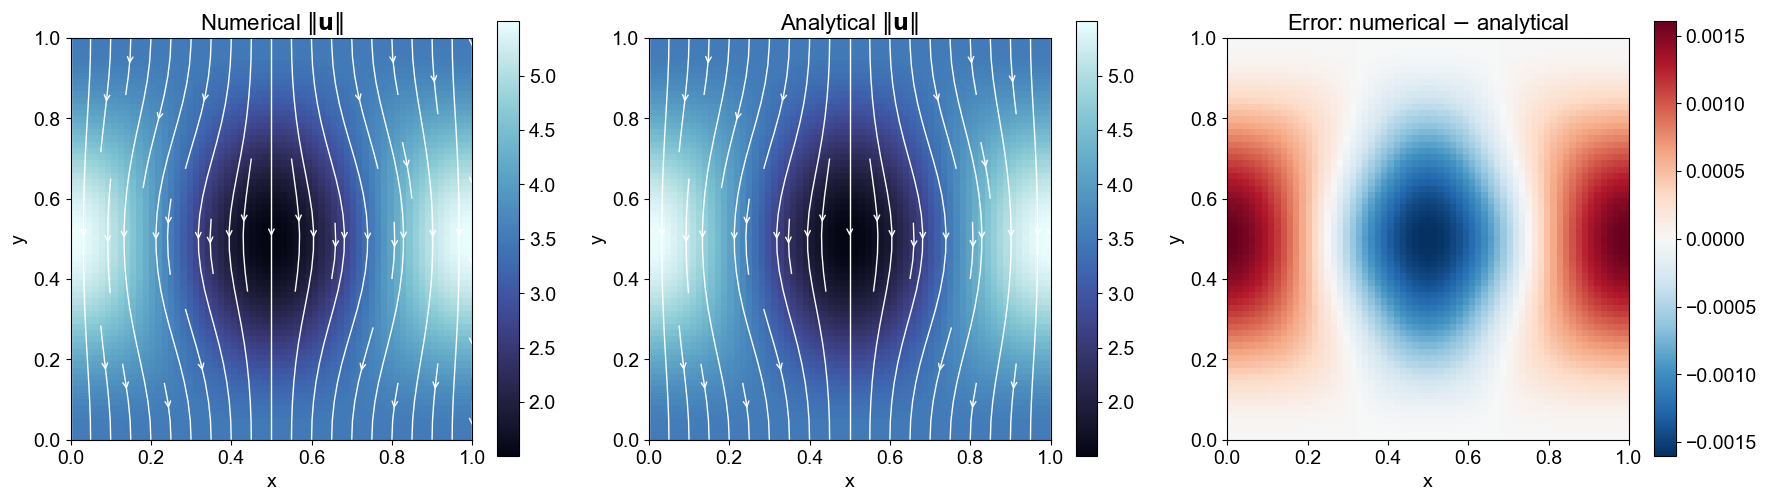

In [5]:
xn = np.linspace(0, 1, Nx + 1)
yn = np.linspace(0, 1, Ny + 1)
XN, YN = np.meshgrid(xn, yn)

Un_num, Vn_num = to_nodes(U_num, V_num)
Un_ana, Vn_ana = to_nodes(U_ana, V_ana)

# shared color scale
vmin = min(u_mag_num.min(), u_mag_ana.min())
vmax = max(u_mag_num.max(), u_mag_ana.max())

# error
err = u_mag_num - u_mag_ana
emax = np.abs(err).max()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

pc_num = ax[0].pcolormesh(XN, YN, u_mag_num, cmap='cmo.ice', vmin=vmin, vmax=vmax)
fig.colorbar(pc_num, ax=ax[0])
ax[0].streamplot(xn, yn, Un_num, Vn_num, color='white', density=0.7, linewidth=1,
                 arrowsize=1, arrowstyle='->')#, broken_streamlines=False)
ax[0].set_title(r'Numerical $\|\mathbf{u}\|$')

pc_ana = ax[1].pcolormesh(XN, YN, u_mag_ana, cmap='cmo.ice', vmin=vmin, vmax=vmax)
fig.colorbar(pc_ana, ax=ax[1])
ax[1].streamplot(xn, yn, Un_ana, Vn_ana, color='white', density=0.7, linewidth=1,
                 arrowsize=1, arrowstyle='->')#, broken_streamlines=False)
ax[1].set_title(r'Analytical $\|\mathbf{u}\|$')

pc_err = ax[2].pcolormesh(XN, YN, err, cmap='RdBu_r', vmin=-emax, vmax=emax)
fig.colorbar(pc_err, ax=ax[2])
ax[2].set_title(r'Error: numerical $-$ analytical')

for a in ax:
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    a.set_aspect('equal')
    a.set_xlabel('x')
    a.set_ylabel('y')
    
plt.savefig("fig1_umag.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

Pressure, numerical against analytical

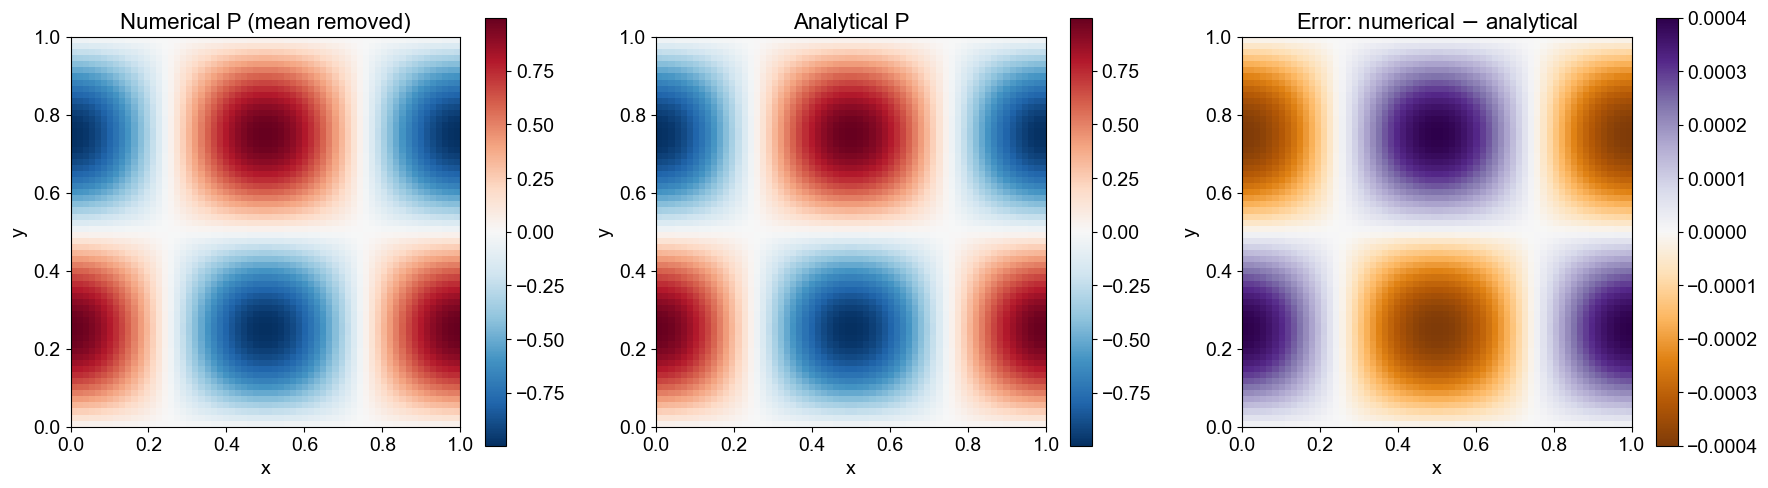

In [6]:
# remove the arbitrary constant from both pressures (P is pinned in one cell)
P_n = P_num - P_num.mean()
P_a = P_ana - P_ana.mean()

# error
p_err = P_n - P_a

# shared color scale, symmetric about zero since the mean is removed
pvmax = max(np.abs(P_n).max(), np.abs(P_a).max())
p_emax = np.abs(p_err).max()

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

p_num = ax[0].pcolormesh(XN, YN, P_n, cmap='RdBu_r', vmin=-pvmax, vmax=pvmax)
fig.colorbar(p_num, ax=ax[0])
ax[0].set_title(r'Numerical P (mean removed)')

p_ana = ax[1].pcolormesh(XN, YN, P_a, cmap='RdBu_r', vmin=-pvmax, vmax=pvmax)
fig.colorbar(p_ana, ax=ax[1])
ax[1].set_title(r'Analytical P')

pc_perr = ax[2].pcolormesh(XN, YN, p_err, cmap='PuOr', vmin=-p_emax, vmax=p_emax)
fig.colorbar(pc_perr, ax=ax[2])
ax[2].set_title(r'Error: numerical $-$ analytical')

for a in ax:
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)
    a.set_aspect('equal')
    a.set_xlabel('x')
    a.set_ylabel('y')

plt.savefig("fig2_pressure.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

#### Problem 2: Convergence

##### Error analysis

For each field, the relative L2 error compares the numerical and analytical values at the grid points where that field lives:

$$e_U = \frac{\|U_{\text{num}} - U_{\text{an}}\|_2}{\|U_{\text{an}}\|_2}$$

and the same for V and P. No interpolation is needed: U is compared on its faces (ghost rows excluded), V on its faces and P at cell centers with the mean removed.

##### Expected order

The centered differences have truncation error proportional to $h^2$. The first- and second-order reference lines are $1/N$ and $1/N^2$. The error curves should be parallel to the second-order line.

In [7]:
n_values = 10 + 10 * np.arange(10)
Uerror_l2 = []
Verror_l2 = []
Perror_l2 = []

for N in n_values:
    Nx = Ny = N
    A, rhs, (nU, nV, nP) = build_system(Nx, Ny)
    x = spla.spsolve(A, rhs)

    U_num = x[:nU].reshape(Ny + 2, Nx)
    V_num = x[nU:nU + nV].reshape(Ny + 1, Nx)
    P_num = x[nU + nV:].reshape(Ny, Nx)

    U_ana, V_ana, P_ana = analytic(Nx, Ny)

    P_num = P_num - P_num.mean()
    P_ana = P_ana - P_ana.mean()

    err_U = (U_num[1:-1] - U_ana[1:-1]).ravel()          # interior rows only, skip ghosts
    Uerror_l2.append(np.linalg.norm(err_U) / np.linalg.norm(U_ana[1:-1].ravel()))

    err_V = (V_num - V_ana).ravel()       
    Verror_l2.append(np.linalg.norm(err_V) / np.linalg.norm(V_ana.ravel()))

    err_P = (P_num - P_ana).ravel()       
    Perror_l2.append(np.linalg.norm(err_P) / np.linalg.norm(P_ana.ravel()))

Uerror_l2 = np.array(Uerror_l2)
Verror_l2 = np.array(Verror_l2)
Perror_l2 = np.array(Perror_l2)

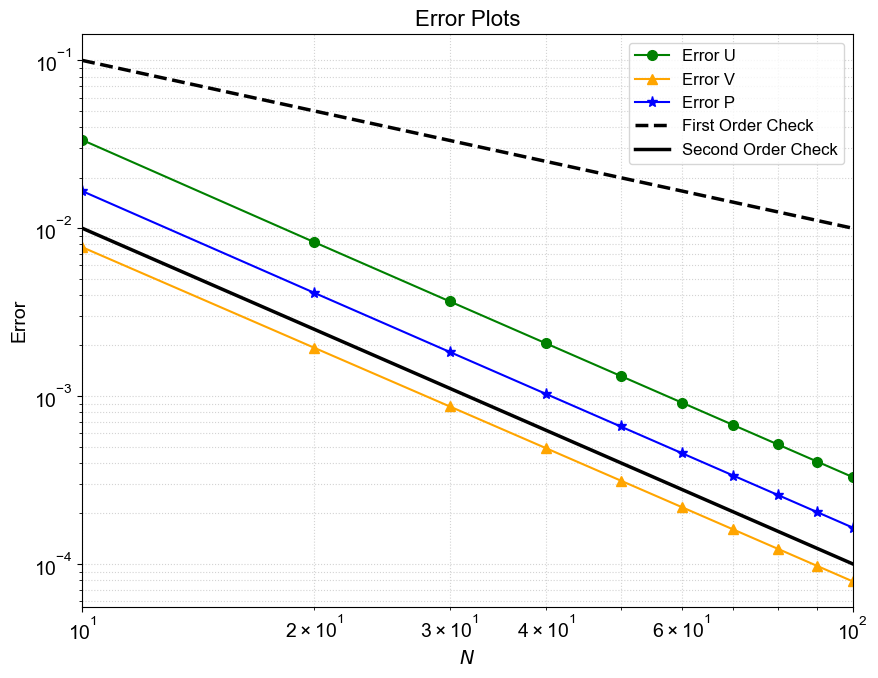

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))


ax.loglog(n_values, Uerror_l2, "o-", color="green", markersize=7, linewidth=1.5, label = r"Error U")
ax.loglog(n_values, Verror_l2, "^-", color="orange", markersize=7, linewidth=1.5, label = r"Error V")
ax.loglog(n_values, Perror_l2, "*-", color="blue", markersize=8, linewidth=1.5, label = r"Error P")
ax.loglog(n_values, 1.0 / n_values,    "k--", linewidth=2.5, label="First Order Check")
ax.loglog(n_values, 1.0 / n_values**2, "k-",  linewidth=2.5, label="Second Order Check")


ax.set_xlabel(r"$N$")
ax.set_xlim(10, 100)
ax.set_ylabel("Error")
ax.set_title("Error Plots")
ax.grid(True, which="both", linestyle=":", color="lightgray")
ax.legend(loc="upper right", frameon=True)

plt.savefig("fig3_convergence.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.savefig("hw1_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

#### Problem 3: Charlies Rule

We implement two things with the solver from Problems 1 and 2:

1. Time the sparse direct solve against an iterative solver (GMRES), and run GMRES with A supplied only as a linear operator, a function that returns $A\mathbf{v}$.
2. Add a Darcy drag term to model flow through a porous medium with four impermeable grains.

#### Part 1: Direct solver against GMRES

Two approaches to solving $A\mathbf{x} = \mathbf{b}$ are compared.

The direct solver, `spsolve`, computes an LU factorization of $A$ and obtains $\mathbf{x}$ by forward and back substitution. Its cost depends only on the size and sparsity pattern of $A$, and the solution is exact to round-off.

GMRES (generalized minimal residual) is an iterative Krylov method. At iteration $k$ it chooses the approximation from the Krylov subspace $\mathrm{span}\{\mathbf{b}, A\mathbf{b}, \dots, A^{k-1}\mathbf{b}\}$ that minimizes the residual $\|\mathbf{b} - A\mathbf{x}_k\|_2$. It terminates when

$$\|\mathbf{b} - A\mathbf{x}_k\|_2 \le \text{tol}\,\|\mathbf{b}\|_2$$

GMRES accesses $A$ only through matrix-vector products $A\mathbf{v}$, so $A$ need not be stored explicitly. A `LinearOperator` represents $A$ by its shape and a `matvec` function. Here `matvec` applies the assembled sparse matrix, so GMRES on the operator should reproduce GMRES on $A$. In a matrix-free implementation, `matvec` would apply the finite-difference stencil directly and $A$ would never be assembled.

Solver settings:

- `restart = 200`: GMRES retains at most 200 basis vectors before restarting from the current iterate. A longer restart costs more memory and work per iteration but avoids discarding the Krylov basis before convergence.
- `rtol = 0.1 h^2`: the discretization error of the scheme is $O(h^2)$, so solving the linear system more accurately than this gains nothing. The tolerance tightens from about $4 \times 10^{-4}$ at N = 16 to $2.4 \times 10^{-5}$ at N = 64.
- `maxiter = 300` restart cycles.
- `M = None`: no preconditioner.

Each solve is timed with `tic` and `toc`. Each solution is assessed by its relative difference from the direct solution and by the U error against the analytical solution of Problem 1.

In [9]:
n_values_t = [16, 32, 64]
t_direct, t_gmres, t_linop = [], [], []
Precon = None                                    # no preconditioner

for N in n_values_t:
    Nx = Ny = N
    h = Lx / Nx
    A, rhs, (nU, nV, nP) = build_system(Nx, Ny)
    tol = 0.1 * h**2                             # tolerance at the level of the O(h^2) discretization error

    # direct sparse solve
    tic = time.perf_counter()
    x_direct = spla.spsolve(A, rhs)
    toc = time.perf_counter()
    t_direct.append(toc - tic)

    # GMRES on the sparse matrix A
    tic = time.perf_counter()
    x_gmres, info = spla.gmres(A, rhs, M=Precon, tol=tol, restart=200, maxiter=300)
    toc = time.perf_counter()
    t_gmres.append(toc - tic)

    # GMRES on A as a linear operator: only the product A @ v is available
    A_op = spla.LinearOperator(A.shape, matvec=lambda v: A @ v)
    tic = time.perf_counter()
    x_linop, info_op = spla.gmres(A_op, rhs, M=Precon, tol=tol, restart=200, maxiter=300)
    toc = time.perf_counter()
    t_linop.append(toc - tic)

    print(f"N = {N}  (unknowns: {A.shape[0]}, tol = {tol:.1e})")
    print(f"  direct      {t_direct[-1]:8.4f} s")
    print(f"  GMRES (A)   {t_gmres[-1]:8.4f} s   converged: {info == 0}")
    print(f"  GMRES (op)  {t_linop[-1]:8.4f} s   converged: {info_op == 0}")

N = 16  (unknowns: 816, tol = 3.9e-04)
  direct        0.0026 s
  GMRES (A)     0.0035 s   converged: True
  GMRES (op)    0.0027 s   converged: True
N = 32  (unknowns: 3168, tol = 9.8e-05)
  direct        0.0146 s
  GMRES (A)     0.0207 s   converged: True
  GMRES (op)    0.0201 s   converged: True
N = 64  (unknowns: 12480, tol = 2.4e-05)
  direct        0.1465 s
  GMRES (A)     0.2267 s   converged: True
  GMRES (op)    0.2206 s   converged: True


N = 32  (unknowns: 3168)
  direct        0.0188 s                       U error 3.22e-03
  GMRES (A)     2.4437 s   3155 iterations   U error 3.20e-03   diff from direct 2.4e-02   converged: True
  GMRES (op)    2.4651 s   3155 iterations   U error 3.20e-03   diff from direct 2.4e-02   converged: True


N = 64  (unknowns: 12480)
  direct        0.1784 s                       U error 8.04e-04
  GMRES (A)     8.3477 s   4006 iterations   U error 7.91e-04   diff from direct 1.3e-02   converged: True
  GMRES (op)    9.6923 s   4006 iterations   U error 7.91e-04   diff from direct 1.3e-02   converged: True


##### Discussion

With a restart length of 200, unpreconditioned GMRES converges at every grid size and its time stays within a factor of about 1.5 of the direct solver. The iteration count grows with N. The restart length is decisive: with `restart = 20`, GMRES needed over several more iterations at N = 32 and failed to converge at N = 64, because each restart discards the Krylov basis before the solution is resolved.

#### Part 2: Stokes-Darcy flow through impermeable grains

The Stokes momentum balance is extended with a linear drag term, giving the Brinkman (Stokes-Darcy) equations:

$$\mu \nabla^2 \mathbf{u} - \alpha(x, y)\,\mathbf{u} - \nabla P = \mathbf{f}, \qquad \nabla \cdot \mathbf{u} = 0, \qquad \alpha = \frac{\mu}{\kappa}$$

where $\kappa$ is the permeability. The term $-\alpha\mathbf{u}$ represents resistance to flow proportional to the local velocity.

- In the open fluid, $\alpha = 0$ and the system reduces to the Stokes equations of Problem 1.
- Inside a grain, $\alpha$ is large. The drag term dominates the viscous term, the velocity is driven toward zero, and the momentum balance approaches Darcy's law, $\mathbf{u} \approx -\frac{\kappa}{\mu}\nabla P$.

A single equation therefore describes both regions. The grain boundaries enter only through the coefficient $\alpha(x, y)$, so no interface conditions are imposed explicitly.

The drag term modifies only the diagonal of the interior momentum rows. At the U face $(i, j)$:

$$\frac{\mu}{h^2}\left(U_{i-1,j} + U_{i+1,j} + U_{i,j-1} + U_{i,j+1} - 4U_{i,j}\right) - \alpha_{i,j}\,U_{i,j} - \frac{P_{i,j} - P_{i-1,j}}{h} = f_{i,j}$$

The diagonal entry changes from $-4\mu/h^2$ to $-4\mu/h^2 - \alpha_{i,j}$, with $\alpha$ evaluated at the U location. The V rows are modified in the same way, with $\alpha$ evaluated at the V location. In `build_system` this is enabled by `darcy=True`. The continuity rows, wall conditions and pressure pin are unchanged, so the discrete velocity remains divergence free.

The body forces are set to zero, f = g = 0 (`source=False`). The manufactured sources of Problem 1 exist only to produce a known exact solution, and no such solution is available here. The flow is driven entirely by the wall condition V = -3.5. Without grains, the solution is uniform flow V = -3.5 at constant pressure. With grains present, the drag they exert must be balanced by a pressure gradient, and this gradient drives the imposed flux through the gaps between them.

*Acknowledgement: The Stokes-Darcy extension in part 2 was developed with assistance from an AI model (Claude, Anthropic, Model: Sonnet).*

##### Grains

Four grains of radius r, one centered in each quadrant. For a point (x, y), `dist_to_grain` returns the distance to the nearest grain center, using the shorter way around in x because the domain is periodic.

$\alpha$ switches from 0 to `alpha_grain` across the grain edge with a smooth step of width w:

$$\alpha(x, y) = \alpha_{\text{grain}} \cdot \tfrac{1}{2}\left(1 - \tanh\frac{d - r}{w}\right)$$

where d is the distance to the nearest grain center. This gives about `alpha_grain` inside (d < r) and about 0 outside (d > r). `alpha_grain = 1e6` means $\kappa = 10^{-6}$. The grains are effectively impermeable as long as `alpha_grain` is much larger than the viscous term $\mu/h^2$, about $1.6 \times 10^4$ at N = 128.

In [10]:
#Grain setup

r = 0.15                     # grain radius
w = 0.005                    # width of the smooth grain edge
alpha_grain = 1e6            # alpha = mu/kappa inside a grain
centers = np.array([(0.25, 0.25), (0.75, 0.25),
                    (0.25, 0.75), (0.75, 0.75)])   # one grain per quadrant

def dist_to_grain(x, y):
    dx = np.abs(x - centers[:, 0])
    dx = np.minimum(dx, Lx - dx)                     # periodic in x
    dy = y - centers[:, 1]
    return np.sqrt(dx**2 + dy**2).min()

def alpha_grains(x, y):
    return alpha_grain * 0.5 * (1 - np.tanh((dist_to_grain(x, y) - r) / w))

In [11]:
#Solve Stokes-Darcy with grains, f = g = 0
Nx, Ny = 128, 128
A, rhs, (nU, nV, nP) = build_system(Nx, Ny, darcy=True, alpha=alpha_grains, source=False)
x = spla.spsolve(A, rhs)

U_num = x[:nU].reshape(Ny + 2, Nx)
V_num = x[nU:nU + nV].reshape(Ny + 1, Nx)
P_num = x[nU + nV:].reshape(Ny, Nx)
P_num = P_num - P_num.mean()

Un_num, Vn_num = to_nodes(U_num, V_num)
u_mag_num = np.sqrt(Un_num**2 + Vn_num**2)

# check: discrete divergence in every cell
h = Lx / Nx
div = (np.roll(U_num[1:-1], -1, axis=1) - U_num[1:-1] + V_num[1:] - V_num[:-1]) / h
print(f"max |div u| = {np.abs(div).max():.1e}")
print(f"max speed = {u_mag_num.max():.2f} (wall speed 3.5)")

max |div u| = 3.7e-07
max speed = 13.41 (wall speed 3.5)


#### Velocity field

Streamlines are seeded along the top wall. Seed points at x = 0.25 and x = 0.75 are excluded: by symmetry U = 0 along these lines.


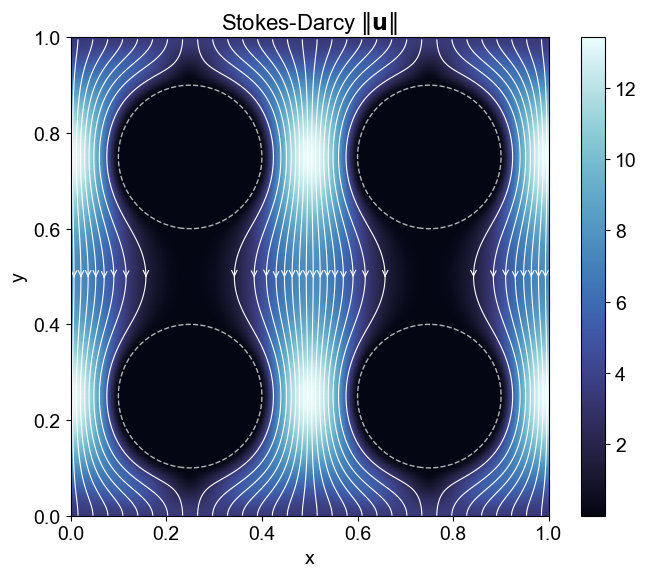

In [12]:
xn = np.linspace(0, 1, Nx + 1)
yn = np.linspace(0, 1, Ny + 1)
XN, YN = np.meshgrid(xn, yn)
D = np.array([[dist_to_grain(x, y) for x in xn] for y in yn])   # for drawing the grain outlines

# streamline seeds along the top wall
x0 = np.linspace(0, 1, 32, endpoint=False) + 0.5 / 32
seeds = np.column_stack([x0, np.full(32, 0.999)])

fig, ax = plt.subplots(figsize=(7.5, 6))

pc_mag = ax.pcolormesh(XN, YN, u_mag_num, cmap='cmo.ice', shading='gouraud')
fig.colorbar(pc_mag, ax=ax)
ax.streamplot(xn, yn, Un_num, Vn_num, start_points=seeds, integration_direction='forward',
              density=10, color='white', linewidth=0.8, arrowsize=1, arrowstyle='->',
              broken_streamlines=False)
ax.contour(XN, YN, D, levels=[r], colors='0.7', linewidths=1, linestyles='--')
ax.set_title(r'Stokes-Darcy $\|\mathbf{u}\|$')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')


plt.savefig("fig4_darcy.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()